In [61]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import torchvision
from torchvision import datasets
from torchvision import transforms

In [62]:
# CIFAR10 https://www.cs.toronto.edu/~kriz/cifar.html

In [63]:
transform = transforms.Compose([
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.491, 0.482, 0.446], 
                       std=[0.247, 0.243, 0.261])
])

In [64]:
train_data = datasets.CIFAR10(
  root="data",
  train=True,
  download=True,
  transform=transform,
  target_transform=None
)

test_data = datasets.CIFAR10(
  root="data",
  train=False,
  download=True,
  transform=transform,
)

c:\Users\servet\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [65]:
image, label = train_data[0]

In [66]:
label

6

In [67]:
image

tensor([[[-1.0511e+00, -1.3052e+00, -1.1940e+00,  ...,  5.2068e-01,
           4.2542e-01,  3.6191e-01],
         [-1.7338e+00, -1.9879e+00, -1.7021e+00,  ..., -3.5008e-02,
          -9.8516e-02, -5.0885e-02],
         [-1.5909e+00, -1.7338e+00, -1.2099e+00,  ..., -1.1439e-01,
          -8.2639e-02, -2.5728e-01],
         ...,
         [ 1.3145e+00,  1.2034e+00,  1.1558e+00,  ...,  5.5243e-01,
          -1.0988e+00, -1.1464e+00],
         [ 8.6997e-01,  7.5883e-01,  9.6523e-01,  ...,  9.3348e-01,
          -4.4780e-01, -6.7008e-01],
         [ 8.2234e-01,  6.7945e-01,  8.5409e-01,  ...,  1.4415e+00,
           4.0954e-01, -3.5008e-02]],

        [[-9.8297e-01, -1.2412e+00, -1.2089e+00,  ...,  1.4670e-01,
           3.3729e-02,  1.7591e-02],
         [-1.6608e+00, -1.9835e+00, -1.8544e+00,  ..., -5.6338e-01,
          -6.4407e-01, -5.7952e-01],
         [-1.5962e+00, -1.8706e+00, -1.5478e+00,  ..., -6.2794e-01,
          -6.2794e-01, -8.0545e-01],
         ...,
         [ 7.5995e-01,  4

In [68]:
image.shape

torch.Size([3, 32, 32])

In [69]:
len(train_data.data)

50000

In [70]:
len(test_data.data)

10000

In [71]:
class_names = train_data.classes

In [72]:
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [73]:
len(class_names)

10

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9084703..2.10758].


Text(0.5, 1.0, 'truck')

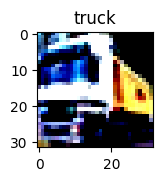

In [74]:
image, label = train_data[1]
image = image.permute(1, 2, 0) # 32, 32, 3
plt.figure(figsize=(1.5, 1.5))
plt.imshow(image)
plt.title(class_names[label])

In [96]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True
)
test_dataloader = DataLoader(dataset=test_data,
                              batch_size=BATCH_SIZE,
                              shuffle=False
)

In [97]:
len(train_dataloader), len(test_dataloader)

(1563, 313)

In [98]:
len(train_dataloader) * 32

50016

In [99]:
train_dataloader.dataset[0][0].shape

torch.Size([3, 32, 32])

In [109]:
class CIFAR10ClassifierCNN(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.block_1 = nn.Sequential(
      nn.Conv2d(in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1),
      nn.ReLU(),
      nn.Conv2d(in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2,
                   stride=2)
    )
    self.block_2 = nn.Sequential(
    nn.Conv2d(in_channels=hidden_units,
              out_channels=hidden_units,
              kernel_size=3,
              stride=1,
              padding=1),
    nn.ReLU(),
    nn.Conv2d(in_channels=hidden_units,
              out_channels=hidden_units,
              kernel_size=3,
              stride=1,
              padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2,
                 stride=2)
    )
    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(in_features=hidden_units*8*8,
                out_features=output_shape)
    )

  def forward(self, x: torch.Tensor):
    return self.classifier(self.block_2(self.block_1(x)))

In [110]:
x = torch.randn(1, 3, 32, 32)
print("Input:", x.shape)

conv1 = nn.Conv2d(3, 10, kernel_size=3, stride=1, padding=1)
conv2 = nn.Conv2d(10, 10, kernel_size=3, stride=1, padding=1)
pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

x = conv1(x)
print("After Conv1:", x.shape)

x = conv2(x)
print("After Conv2:", x.shape)

x = pool1(x)
print("After MaxPool1:", x.shape)

conv3 = nn.Conv2d(10, 10, kernel_size=3, stride=1, padding=1)
conv4 = nn.Conv2d(10, 10, kernel_size=3, stride=1, padding=1)
pool2 = nn.MaxPool2d(2, 2)

x = conv3(x)
print("After Conv3:", x.shape)

x = conv4(x)
print("After Conv4:", x.shape)

x = pool2(x)
print("After MaxPool2:", x.shape)

Input: torch.Size([1, 3, 32, 32])
After Conv1: torch.Size([1, 10, 32, 32])
After Conv2: torch.Size([1, 10, 32, 32])
After MaxPool1: torch.Size([1, 10, 16, 16])
After Conv3: torch.Size([1, 10, 16, 16])
After Conv4: torch.Size([1, 10, 16, 16])
After MaxPool2: torch.Size([1, 10, 8, 8])


In [111]:
# flatten size: 10 * 8 * 8

In [112]:
torch.manual_seed(42)
model = CIFAR10ClassifierCNN(input_shape=3, 
                             hidden_units=32, 
                             output_shape=len(class_names))

In [113]:
model

CIFAR10ClassifierCNN(
  (block_1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=10, bias=True)
  )
)

In [114]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(),
                             lr=0.001)

In [115]:
def calculate_accuracy(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() 
    acc = (correct / len(y_pred)) * 100 
    return acc

In [116]:
torch.manual_seed(42)

epochs = 10

for epoch in range(epochs):
   train_loss = 0

   for batch, (X, y) in enumerate(train_dataloader):
      model.train()

      y_pred = model(X)
      loss = loss_fn(y_pred, y)

      train_loss += loss

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      if batch % 500 == 0:
        print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

   train_loss /= len(train_dataloader)

   test_loss, test_acc = 0, 0
   model.eval()
   with torch.inference_mode():
      for X, y in test_dataloader:
         test_pred = model(X)
         test_loss += loss_fn(test_pred, y)

         test_acc += calculate_accuracy(y_true=y, y_pred=test_pred.argmax(dim=1))

      test_loss /= len(test_dataloader)
      test_acc /= len(test_dataloader)

   print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 1.30552 | Test loss: 1.00341, Test acc: 65.18%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 0.89486 | Test loss: 0.82281, Test acc: 71.64%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 0.76934 | Test loss: 0.80601, Test acc: 72.04%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 0.69006 | Test loss: 0.78638, Test acc: 73.27%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 0.63277 | Test loss: 0.79384, Test acc: 73.15%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

In [117]:
def evaluate_model_performance(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, accuracy_function):
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_function(y_true=y, y_pred=y_pred.argmax(dim=1)) 

        loss /= len(data_loader)
        acc /= len(data_loader)
        
    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_acc": acc}

In [118]:
model_results = evaluate_model_performance(model=model, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_function=calculate_accuracy)

In [119]:
model_results

{'model_name': 'CIFAR10ClassifierCNN',
 'model_loss': 0.8655547499656677,
 'model_acc': 73.43250798722045}

In [120]:
def make_predictions(model: torch.nn.Module, data: list):
    """
    data: [img_tensor, img_tensor, ...]  # her biri [C, H, W]
    return: [N, num_classes] olasılık tensörü
    """
    pred_probs = []
    model.eval()

    with torch.inference_mode():
        for sample in data:
            # [C, H, W] -> [1, C, H, W]
            sample = sample.unsqueeze(0)

            # Logits al
            pred_logit = model(sample)    # shape: [1, num_classes]

            # Softmax ile olasılığa çevir
            prob = torch.softmax(pred_logit, dim=1)  # [1, num_classes]

            # Batch boyutunu sıkıştır
            pred_probs.append(prob.squeeze(0))       # [num_classes]

    # Hepsini birleştir → [N, num_classes]
    return torch.stack(pred_probs)

In [121]:
import random
def show_random_predictions(model, dataset, class_names, n=9):
    model.eval()
    
    plt.figure(figsize=(4, 4))

    # random 9 index seç
    indices = random.sample(range(len(dataset)), n)

    with torch.inference_mode():
        for i, idx in enumerate(indices):
            img, true_label = dataset[idx]

            # modele uygun hale getir
            img_input = img.unsqueeze(0)  
            logits = model(img_input)
            pred_label = logits.argmax(dim=1).item()

            # görseli çizmek için permute
            img_show = img.permute(1, 2, 0)

            # doğru mu yanlış mı?
            correct = (pred_label == true_label)
            color = "green" if correct else "red"

            # subplot
            plt.subplot(3, 3, i + 1)
            plt.imshow(img_show)
            plt.axis("off")

            plt.title(
                f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}",
                color=color,
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7970945..1.7169257].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8060195..1.7770264].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9561007..1.927278].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9402239..1.8702073].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7737433..1.7114393].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9028484..1.7169257].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9878542

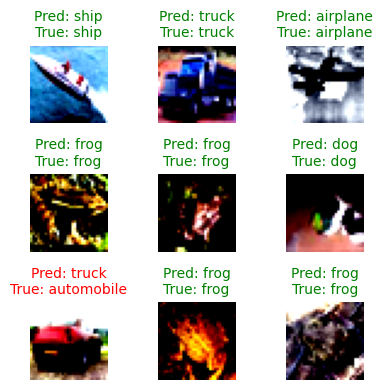

In [122]:
show_random_predictions(model, test_data, class_names)